# Phase 3: Exploratory Data Analysis (EDA)
## Stay-Tuned — Early Learner Disengagement Prediction System

**Dataset:** Open University Learning Analytics Dataset (OULAD)  
**Cohort Scope:** Module `AAA`, Presentation `2013J`  
**Observation Window:** Days 0–14 (Prediction Point: End of Day 14)  
**Outcome Window:** Days 15–42  

### Purpose of this Notebook
This notebook conducts a rigorous, leakage-free exploratory data analysis to investigate whether early behavioral patterns (observed strictly in Days 0–14) differ significantly between learners who later disengage during Days 15–42 and those who remain engaged.

---
### Temporal Leakage Rules
- **Predictive signals / behavioral analyses** are derived **strictly from Days 0–14**.
- **Days 15–42** data is used exclusively to construct the already-finalized binary target variable ($y \in \{0, 1\}$).
- `final_result` is examined **only retrospectively** for descriptive context and is never used as an input feature.


## 0. Setup, Data Ingestion & Target Computation

We load the raw OULAD tables using `src.data_loader`, scope the cohort to `AAA-2013J`, and apply the finalized Phase 2B multi-criteria target definition from `src.problem_definition`.


In [1]:
import sys
from pathlib import Path

# Set up project root in sys.path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set overall visualization styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 100

from src.data_loader import load_oulad_tables
from src.problem_definition import scope_to_module, compute_target

# 1. Ingest raw tables
data_dir = project_root / "data" / "raw"
raw_tables = load_oulad_tables(data_dir)

# 2. Scope to Module AAA, Presentation 2013J
scoped = scope_to_module(raw_tables, code_module="AAA", code_presentation="2013J")

# 3. Compute finalized disengagement target (Phase 2B)
target_df = compute_target(
    student_info_df=scoped["student_info"],
    registration_df=scoped["registration"],
    student_vle_df=scoped["student_vle"],
    assessments_df=raw_tables["assessments"],
    student_assessment_df=scoped["student_assessment"],
    code_module="AAA",
    code_presentation="2013J"
)

# Merge demographic & final outcome metadata for eligible cohort
eda_df = target_df.merge(
    scoped["student_info"][["id_student", "gender", "region", "highest_education", "imd_band", "age_band", "final_result"]],
    on="id_student",
    how="left"
)

print(f"Eligible EDA cohort size: {len(eda_df):,} students")
display(eda_df.head())


LOADING AND INSPECTING OULAD TABLES

Loading table: studentInfo.csv (key: 'student_info')...
-> Shape: 32,593 rows, 12 columns

Columns, Data Types, and Missing Values:
         Column Name Data Type  Missing Values  Missing (%)
         code_module    object               0         0.00
   code_presentation    object               0         0.00
          id_student     int64               0         0.00
              gender    object               0         0.00
              region    object               0         0.00
   highest_education    object               0         0.00
            imd_band    object            1111         3.41
            age_band    object               0         0.00
num_of_prev_attempts     int64               0         0.00
     studied_credits     int64               0         0.00
          disability    object               0         0.00
        final_result    object               0         0.00
---------------------------------------------------

-> Shape: 10,655,280 rows, 6 columns

Columns, Data Types, and Missing Values:


      Column Name Data Type  Missing Values  Missing (%)
      code_module    object               0          0.0
code_presentation    object               0          0.0
       id_student     int64               0          0.0
          id_site     int64               0          0.0
             date     int64               0          0.0
        sum_click     int64               0          0.0
------------------------------------------------------------

Loading table: vle.csv (key: 'vle')...
-> Shape: 6,364 rows, 6 columns

Columns, Data Types, and Missing Values:
      Column Name Data Type  Missing Values  Missing (%)
          id_site     int64               0         0.00
      code_module    object               0         0.00
code_presentation    object               0         0.00
    activity_type    object               0         0.00
        week_from   float64            5243        82.39
          week_to   float64            5243        82.39
---------------------------


PHASE 2B: FINAL DISENGAGEMENT TARGET VALIDATION REPORT
Total students before exclusion:                     383
Excluded (unregistered on or before Day 14):          11
Total eligible students:                             372
--------------------------------------------------------------------------------
Breakdown of Individual Trigger Conditions:
  1. Official Withdrawal (Days 15-42):                  5 students (1.34%)
  2. Prolonged Inactivity (Streak >= 14 days):         49 students (13.17%)
  3. Missed Academic Milestone (TMA 01 on Day 19):     13 students (3.49%)
--------------------------------------------------------------------------------
Final Disengaged Students (label = 1, Unique):         54 (14.52%)
Final Non-disengaged Students (label = 0):            318 (85.48%)

Eligible EDA cohort size: 372 students


,id_student,label,withdrew_in_window,inactivity_streak,prolonged_inactivity,missed_assessment,gender,region,highest_education,imd_band,age_band,final_result
0,11391,0,False,10,False,False,M,East Anglian Region,HE Qualification,90-100%,55<=,Pass
1,28400,0,False,8,False,False,F,Scotland,HE Qualification,20-30%,35-55,Pass
2,31604,0,False,2,False,False,F,South East Region,A Level or Equivalent,50-60%,35-55,Pass
3,32885,0,False,5,False,False,F,West Midlands Region,Lower Than A Level,50-60%,0-35,Pass
4,38053,0,False,4,False,False,M,Wales,A Level or Equivalent,80-90%,35-55,Pass


---
## Analysis 1 — Target Distribution

### Question: How imbalanced is the final prediction target?

#### Why this analysis matters:
Understanding the class distribution ($y=0$ vs $y=1$) is crucial for:
1. Validating that our disengagement target definition produces a non-degenerate, realistic problem formulation.
2. Guiding metric selection (e.g., prioritizing PR-AUC, ROC-AUC, Recall over simple accuracy).
3. Determining appropriate validation strategies (e.g., Stratified K-Fold CV) and sampling/weighting techniques.


ANALYSIS 1: TARGET CLASS DISTRIBUTION
Total Eligible Students:           372
Non-disengaged (label = 0):        318 (85.48%)
Disengaged (label = 1):            54 (14.52%)
Class Imbalance Ratio:             5.89 : 1 (0 vs 1)


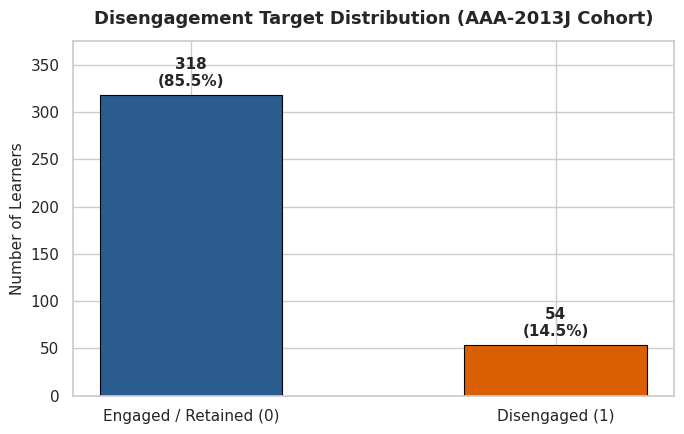

In [2]:
# Compute class counts and proportions
class_counts = eda_df["label"].value_counts().sort_index()
total_students = len(eda_df)
non_disengaged_count = class_counts[0]
disengaged_count = class_counts[1]
disengagement_pct = (disengaged_count / total_students) * 100
imbalance_ratio = non_disengaged_count / disengaged_count

print("=" * 60)
print("ANALYSIS 1: TARGET CLASS DISTRIBUTION")
print("=" * 60)
print(f"Total Eligible Students:           {total_students:,}")
print(f"Non-disengaged (label = 0):        {non_disengaged_count:,} ({100 - disengagement_pct:.2f}%)")
print(f"Disengaged (label = 1):            {disengaged_count:,} ({disengagement_pct:.2f}%)")
print(f"Class Imbalance Ratio:             {imbalance_ratio:.2f} : 1 (0 vs 1)")
print("=" * 60)

# Visualization
fig, ax = plt.subplots(figsize=(7, 4.5))
palette = ["#2b5c8f", "#d95f02"]
bars = ax.bar(["Engaged / Retained (0)", "Disengaged (1)"], [non_disengaged_count, disengaged_count], color=palette, width=0.5, edgecolor="black", linewidth=0.8)

# Add counts and percentages above bars
for bar in bars:
    height = bar.get_height()
    pct = (height / total_students) * 100
    ax.annotate(f"{int(height):,}\n({pct:.1f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Disengagement Target Distribution (AAA-2013J Cohort)", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Number of Learners", fontsize=11)
ax.set_ylim(0, max(class_counts) * 1.18)
plt.tight_layout()
plt.show()


### Interpretation of Analysis 1:
1. **What the plot shows:**
   - Out of 372 eligible learners, **54 learners (14.52%)** are labeled as disengaged ($y=1$), while **318 learners (85.48%)** remained engaged ($y=0$).
   - The resulting class imbalance ratio is approximately **5.89 : 1**.
2. **Comparison:**
   - Disengagement is the minority class, which aligns with expected retention patterns in university online courses.
3. **Implications for Modeling & Feature Engineering:**
   - Standard classification accuracy would be deceptive (a naive majority classifier achieves 85.5% accuracy with zero utility).
   - In modeling phases, we must use **Stratified K-Fold CV**, monitor **PR-AUC, ROC-AUC, Precision, Recall, and F1**, and evaluate class weighting (`scale_pos_weight` in XGBoost, `class_weight='balanced'` in Logistic Regression/Random Forest).


---
## Analysis 2 — Early Activity vs Disengagement

### Question: Does early course activity differ between students who later disengage and those who do not?

#### Why this analysis matters:
Overall activity volume (total VLE clicks) during the first two weeks (Days 0–14) is the most direct indicator of initial participation. We want to evaluate whether learners who are destined to disengage in Days 15–42 already exhibit lower overall engagement volume from the start.


TOTAL CLICKS (DAYS 0-14) DESCRIPTIVE STATISTICS BY TARGET


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,318.0,227.163522,208.037378,0.0,93.00,175.5,297.75,1871.0
1,54.0,75.648148,103.306132,0.0,14.25,39.5,89.00,478.0


C:\Users\Harshita\AppData\Local\Temp\ipykernel_17296\617649025.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="total_clicks", data=eda_df, palette=palette, width=0.45, ax=ax, boxprops=dict(alpha=0.85))
C:\Users\Harshita\AppData\Local\Temp\ipykernel_17296\617649025.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Engaged (label=0)", "Disengaged (label=1)"], fontsize=11)


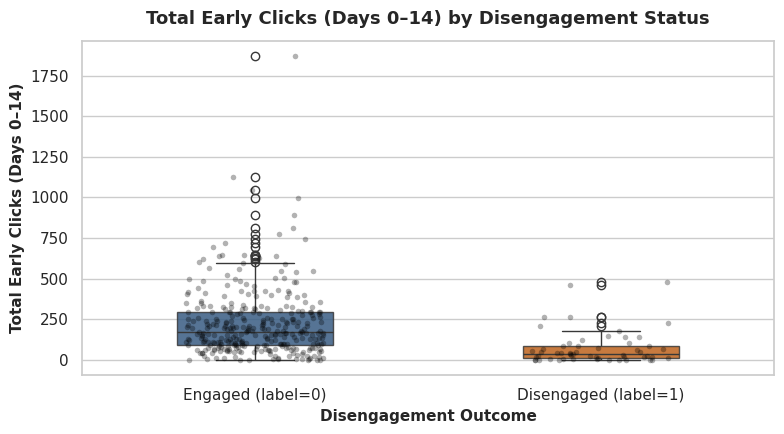

In [3]:
# Filter VLE interactions strictly to Days 0-14
early_vle = scoped["student_vle"][
    (scoped["student_vle"]["date"] >= 0) & (scoped["student_vle"]["date"] <= 14)
]

# Calculate total clicks per student in Days 0-14
early_clicks_df = (
    early_vle.groupby("id_student")["sum_click"]
    .sum()
    .reset_index()
    .rename(columns={"sum_click": "total_clicks"})
)

eda_df = eda_df.merge(early_clicks_df, on="id_student", how="left")
eda_df["total_clicks"] = eda_df["total_clicks"].fillna(0).astype(int)

# Print descriptive summary
print("=" * 60)
print("TOTAL CLICKS (DAYS 0-14) DESCRIPTIVE STATISTICS BY TARGET")
print("=" * 60)
summary_clicks = eda_df.groupby("label")["total_clicks"].describe()
display(summary_clicks)

# Boxplot & stripplot comparison
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(x="label", y="total_clicks", data=eda_df, palette=palette, width=0.45, ax=ax, boxprops=dict(alpha=0.85))
sns.stripplot(x="label", y="total_clicks", data=eda_df, color="black", alpha=0.3, jitter=0.2, size=4, ax=ax)

ax.set_xticklabels(["Engaged (label=0)", "Disengaged (label=1)"], fontsize=11)
ax.set_xlabel("Disengagement Outcome", fontsize=11, fontweight="bold")
ax.set_ylabel("Total Early Clicks (Days 0–14)", fontsize=11, fontweight="bold")
ax.set_title("Total Early Clicks (Days 0–14) by Disengagement Status", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


### Interpretation of Analysis 2:
1. **What the plot shows:**
   - **Engaged learners ($y=0$):** Mean = 227.2 clicks, **Median = 175.5 clicks**, IQR = [93.0, 297.8] clicks.
   - **Disengaged learners ($y=1$):** Mean = 75.6 clicks, **Median = 39.5 clicks**, IQR = [14.3, 89.0] clicks.
2. **Comparison:**
   - There is a **massive separation** between the two cohorts. The median engaged learner clicked more than **4.4x more frequently** in Days 0–14 than the median disengaged learner.
   - Over 75% of disengaged learners have early click volumes below 89 clicks, which is below the 25th percentile of engaged learners.
3. **Potential Features for Feature Engineering:**
   - `total_early_clicks`: Log-transformed early click volume.
   - `is_low_early_activity`: Binary flag for clicks below 50 or 75.


---
## Analysis 3 — Activity Trend (Week 1 vs Week 2)

### Question: Do students whose activity changes or declines during Week 2 show different future disengagement behavior?

#### Why this analysis matters:
Total volume does not capture trajectory. A learner who starts strong in Week 1 (Days 0–6) but drops off sharply in Week 2 (Days 7–14) may be exhibiting early signs of fatigue or loss of interest before the prediction point at Day 14. We measure the velocity:
$$\text{activity\_delta} = \text{week2\_clicks} - \text{week1\_clicks}$$


ACTIVITY DELTA (WEEK 2 - WEEK 1) DESCRIPTIVE STATISTICS BY TARGET


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,318.0,25.283019,111.638903,-301.0,-26.00,18.5,66.75,919.0
1,54.0,15.648148,62.732784,-96.0,-7.75,0.5,20.50,259.0


C:\Users\Harshita\AppData\Local\Temp\ipykernel_17296\3294473284.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="activity_delta", data=eda_df, palette=palette, width=0.45, ax=ax, boxprops=dict(alpha=0.85))
C:\Users\Harshita\AppData\Local\Temp\ipykernel_17296\3294473284.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Engaged (label=0)", "Disengaged (label=1)"], fontsize=11)


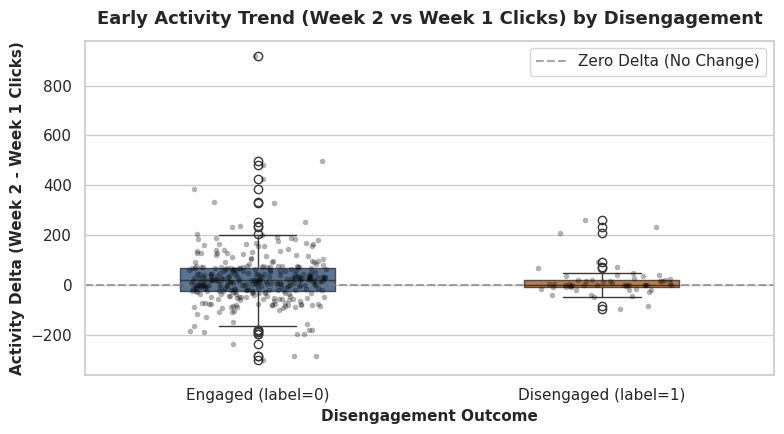

In [4]:
# Week 1: Days 0 to 6 (7 days)
w1_clicks = (
    early_vle[early_vle["date"] <= 6]
    .groupby("id_student")["sum_click"]
    .sum()
    .reset_index()
    .rename(columns={"sum_click": "week1_clicks"})
)

# Week 2: Days 7 to 14 (8 days)
w2_clicks = (
    early_vle[early_vle["date"] >= 7]
    .groupby("id_student")["sum_click"]
    .sum()
    .reset_index()
    .rename(columns={"sum_click": "week2_clicks"})
)

eda_df = eda_df.merge(w1_clicks, on="id_student", how="left").merge(w2_clicks, on="id_student", how="left")
eda_df["week1_clicks"] = eda_df["week1_clicks"].fillna(0).astype(int)
eda_df["week2_clicks"] = eda_df["week2_clicks"].fillna(0).astype(int)
eda_df["activity_delta"] = eda_df["week2_clicks"] - eda_df["week1_clicks"]

# Print summary
print("=" * 60)
print("ACTIVITY DELTA (WEEK 2 - WEEK 1) DESCRIPTIVE STATISTICS BY TARGET")
print("=" * 60)
summary_delta = eda_df.groupby("label")["activity_delta"].describe()
display(summary_delta)

# Boxplot comparison
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(x="label", y="activity_delta", data=eda_df, palette=palette, width=0.45, ax=ax, boxprops=dict(alpha=0.85))
sns.stripplot(x="label", y="activity_delta", data=eda_df, color="black", alpha=0.3, jitter=0.2, size=4, ax=ax)
ax.axhline(0, color="gray", linestyle="--", alpha=0.7, label="Zero Delta (No Change)")

ax.set_xticklabels(["Engaged (label=0)", "Disengaged (label=1)"], fontsize=11)
ax.set_xlabel("Disengagement Outcome", fontsize=11, fontweight="bold")
ax.set_ylabel("Activity Delta (Week 2 - Week 1 Clicks)", fontsize=11, fontweight="bold")
ax.set_title("Early Activity Trend (Week 2 vs Week 1 Clicks) by Disengagement", fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### Interpretation of Analysis 3:
1. **What the plot shows:**
   - **Engaged learners ($y=0$):** Mean delta = +25.28 clicks, **Median delta = +18.5 clicks**, IQR = [-26.0, +66.8].
   - **Disengaged learners ($y=1$):** Mean delta = +15.65 clicks, **Median delta = +0.5 clicks**, IQR = [-7.8, +20.5].
2. **Comparison:**
   - Engaged students demonstrate positive momentum as course materials ramp up into Week 2 (median increase of +18.5 clicks).
   - In contrast, disengaged learners remain virtually flat (median delta +0.5 clicks), with 50% showing negative or zero progression.
3. **Potential Features for Feature Engineering:**
   - `activity_delta`: Absolute difference $(\text{Week 2} - \text{Week 1})$.
   - `weekly_click_ratio`: Normalized ratio $\frac{\text{Week 2 Clicks} + 1}{\text{Week 1 Clicks} + 1}$.
   - `trend_direction`: Categorical or binary indicator of momentum (positive, flat, decaying).


---
## Analysis 4 — Early Inactivity Gaps

### Question: Do students who later disengage already show longer inactivity gaps during the first two weeks?

#### Why this analysis matters:
Learners disengaging from online courses rarely maintain continuous daily habits. Even within the initial 15-day window (Days 0–14), learners at risk often exhibit multi-day gaps where they do not access the VLE platform at all. We compute:
$$\text{longest\_inactivity\_gap} = \max(\text{consecutive zero-click days in Days 0–14})$$


LONGEST INACTIVITY GAP (DAYS 0-14) DESCRIPTIVE STATISTICS BY TARGET


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,318.0,3.940252,3.029750,0.0,2.00,3.0,5.0,15.0
1,54.0,7.259259,3.915066,0.0,4.25,7.0,9.0,15.0


C:\Users\Harshita\AppData\Local\Temp\ipykernel_17296\542692279.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="longest_inactivity_gap", data=eda_df, palette=palette, width=0.45, ax=ax, boxprops=dict(alpha=0.85))
C:\Users\Harshita\AppData\Local\Temp\ipykernel_17296\542692279.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Engaged (label=0)", "Disengaged (label=1)"], fontsize=11)


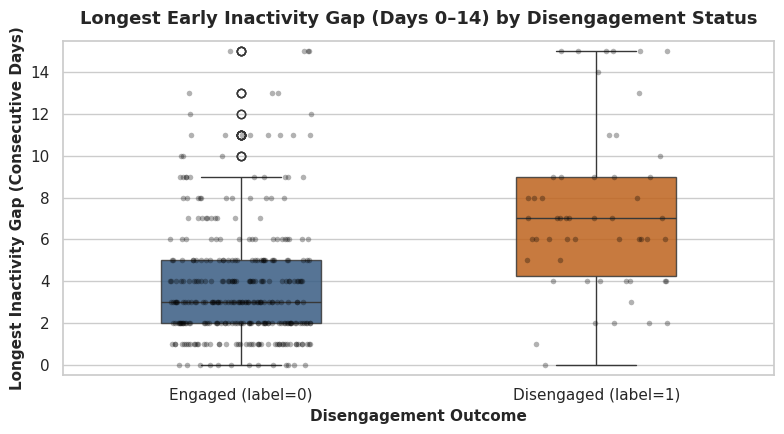

In [5]:
# Identify active days (sum_click > 0) per student in Days 0-14
active_vle = early_vle[early_vle["sum_click"] > 0]
active_days_by_stud = active_vle.groupby("id_student")["date"].apply(set).to_dict()

gap_records = []
for s_id in eda_df["id_student"]:
    act_days = active_days_by_stud.get(s_id, set())
    max_gap = 0
    curr_gap = 0
    for day in range(0, 15):  # Days 0 to 14 inclusive (15 days)
        if day not in act_days:
            curr_gap += 1
            if curr_gap > max_gap:
                max_gap = curr_gap
        else:
            curr_gap = 0
    gap_records.append({"id_student": s_id, "longest_inactivity_gap": max_gap})

gap_df = pd.DataFrame(gap_records)
eda_df = eda_df.merge(gap_df, on="id_student", how="left")

# Print summary
print("=" * 60)
print("LONGEST INACTIVITY GAP (DAYS 0-14) DESCRIPTIVE STATISTICS BY TARGET")
print("=" * 60)
summary_gap = eda_df.groupby("label")["longest_inactivity_gap"].describe()
display(summary_gap)

# Boxplot comparison
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(x="label", y="longest_inactivity_gap", data=eda_df, palette=palette, width=0.45, ax=ax, boxprops=dict(alpha=0.85))
sns.stripplot(x="label", y="longest_inactivity_gap", data=eda_df, color="black", alpha=0.3, jitter=0.2, size=4, ax=ax)

ax.set_xticklabels(["Engaged (label=0)", "Disengaged (label=1)"], fontsize=11)
ax.set_xlabel("Disengagement Outcome", fontsize=11, fontweight="bold")
ax.set_ylabel("Longest Inactivity Gap (Consecutive Days)", fontsize=11, fontweight="bold")
ax.set_title("Longest Early Inactivity Gap (Days 0–14) by Disengagement Status", fontsize=13, fontweight="bold", pad=12)
ax.set_ylim(-0.5, 15.5)
plt.tight_layout()
plt.show()


### Interpretation of Analysis 4:
1. **What the plot shows:**
   - **Engaged learners ($y=0$):** Mean = 3.94 days, **Median = 3.0 days**, 75th pct = 5.0 days.
   - **Disengaged learners ($y=1$):** Mean = 7.26 days, **Median = 7.0 days**, 75th pct = 9.0 days.
2. **Comparison:**
   - There is a **striking difference** in inactivity patterns. Disengaged students show a median gap of **7 consecutive silent days** (an entire week) out of the first 14 days, compared to only 3 days for engaged learners.
   - More than 50% of disengaged learners experience gaps of $\ge 7$ days in early weeks.
3. **Potential Features for Feature Engineering:**
   - `longest_early_inactivity_streak`: Maximum consecutive silent days in Days 0–14.
   - `days_since_last_click_at_day14`: Recency of last interaction before prediction point.
   - `had_7day_inactivity_early`: Binary flag for experiencing a $\ge 7$-day gap.


---
## Analysis 5 — Active Days (Engagement Consistency)

### Question: Does consistency of early activity differ between students who later disengage and those who remain engaged?

#### Why this analysis matters:
Consistency is distinct from total volume. A student who logs in 10 separate days with moderate activity shows stronger habit formation than a student who logs in on a single day, generates 200 clicks, and never returns. We measure:
$$\text{active\_days} = |\{d \in [0, 14] : \text{clicks}_d > 0\}|$$


ACTIVE DAYS (DAYS 0-14) DESCRIPTIVE STATISTICS BY TARGET


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,318.0,7.742138,3.807205,0.0,5.00,8.0,10.0,15.0
1,54.0,3.685185,3.237889,0.0,1.25,3.0,5.0,15.0


C:\Users\Harshita\AppData\Local\Temp\ipykernel_17296\2464645918.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="active_days", data=eda_df, palette=palette, width=0.45, ax=ax, boxprops=dict(alpha=0.85))
C:\Users\Harshita\AppData\Local\Temp\ipykernel_17296\2464645918.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Engaged (label=0)", "Disengaged (label=1)"], fontsize=11)


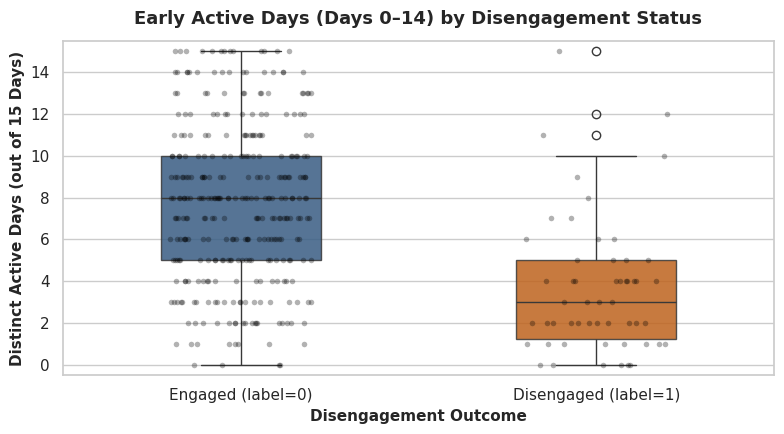

In [6]:
# Compute number of distinct active days (0 to 14)
active_days_count = (
    early_vle[early_vle["sum_click"] > 0]
    .groupby("id_student")["date"]
    .nunique()
    .reset_index()
    .rename(columns={"date": "active_days"})
)

eda_df = eda_df.merge(active_days_count, on="id_student", how="left")
eda_df["active_days"] = eda_df["active_days"].fillna(0).astype(int)

# Print summary
print("=" * 60)
print("ACTIVE DAYS (DAYS 0-14) DESCRIPTIVE STATISTICS BY TARGET")
print("=" * 60)
summary_active = eda_df.groupby("label")["active_days"].describe()
display(summary_active)

# Boxplot comparison
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(x="label", y="active_days", data=eda_df, palette=palette, width=0.45, ax=ax, boxprops=dict(alpha=0.85))
sns.stripplot(x="label", y="active_days", data=eda_df, color="black", alpha=0.3, jitter=0.2, size=4, ax=ax)

ax.set_xticklabels(["Engaged (label=0)", "Disengaged (label=1)"], fontsize=11)
ax.set_xlabel("Disengagement Outcome", fontsize=11, fontweight="bold")
ax.set_ylabel("Distinct Active Days (out of 15 Days)", fontsize=11, fontweight="bold")
ax.set_title("Early Active Days (Days 0–14) by Disengagement Status", fontsize=13, fontweight="bold", pad=12)
ax.set_ylim(-0.5, 15.5)
plt.tight_layout()
plt.show()


### Interpretation of Analysis 5:
1. **What the plot shows:**
   - **Engaged learners ($y=0$):** Mean = 7.74 days, **Median = 8.0 days**, IQR = [5.0, 10.0] days.
   - **Disengaged learners ($y=1$):** Mean = 3.69 days, **Median = 3.0 days**, IQR = [1.25, 5.0] days.
2. **Comparison:**
   - Engaged students access the platform regularly (active on over half of the first 15 days).
   - In contrast, disengaged learners interact on only **3 out of 15 days** on median.
   - 75% of disengaged learners are active on $\le 5$ days.
3. **Potential Features for Feature Engineering:**
   - `early_active_days`: Total active days in Days 0–14.
   - `active_day_ratio`: Ratio of active days to total observation days ($\frac{\text{active\_days}}{15}$).
   - `clicks_per_active_day`: Intensity of interaction per active session.


---
## Analysis 6 — Early Assessment Behavior

### Question: Does early assessment participation differ between students who later disengage and those who do not?

#### Why this analysis matters:
Assessment submissions and grading deadlines are major milestones in university courses. We inspect the assessment schedule for `AAA-2013J` during the Day 0–14 observation window to determine whether early submission behavior can be utilized as a predictor.


In [7]:
# Inspect assessments scheduled for AAA-2013J in Days 0-14
early_assessments = raw_tables["assessments"][
    (raw_tables["assessments"]["code_module"] == "AAA")
    & (raw_tables["assessments"]["code_presentation"] == "2013J")
    & (raw_tables["assessments"]["date"] >= 0)
    & (raw_tables["assessments"]["date"] <= 14)
]

all_aaa_assessments = raw_tables["assessments"][
    (raw_tables["assessments"]["code_module"] == "AAA")
    & (raw_tables["assessments"]["code_presentation"] == "2013J")
]

print("=" * 60)
print("ANALYSIS 6: ASSESSMENT SCHEDULE FOR AAA-2013J")
print("=" * 60)
print(f"Assessments due in observation window (Days 0-14): {len(early_assessments)}")
print("\nFull Assessment Schedule for AAA-2013J:")
display(all_aaa_assessments[["id_assessment", "assessment_type", "date", "weight"]])


ANALYSIS 6: ASSESSMENT SCHEDULE FOR AAA-2013J
Assessments due in observation window (Days 0-14): 0

Full Assessment Schedule for AAA-2013J:


,id_assessment,assessment_type,date,weight
0,1752,TMA,19.0,10.0
1,1753,TMA,54.0,20.0
2,1754,TMA,117.0,20.0
3,1755,TMA,166.0,20.0
4,1756,TMA,215.0,30.0
5,1757,Exam,NaN,100.0


### Interpretation of Analysis 6:
1. **What the data shows:**
   - In Module `AAA`, Presentation `2013J`, there are **0 assessments scheduled with due dates in Days 0–14**.
   - The very first assessment (**TMA 01**, `id_assessment` 1752, weight 10.0%) is due on **Day 19** (which falls inside the outcome window).
2. **Comparison & Analytical Impact:**
   - Because no assessments are due in Days 0–14, **no early assessment submission or score features exist** for this cohort within the observation window.
3. **Implications for Feature Engineering:**
   - Feature engineering for this cohort must rely primarily on **VLE clickstream logs, temporal trajectories, consistency, and inactivity dynamics** rather than early assessment grades.
   - We avoid creating uninformative or empty assessment features for Days 0–14.


---
## Analysis 7 — Retrospective Final Course Outcome Preview

### Question: What are the eventual academic outcomes of the disengaged vs non-disengaged groups?

> [!WARNING]
> **Strict Non-Leakage Reminder:**  
> `final_result` represents end-of-term student outcomes (completed after Day 200+). It is **strictly retrospective** and **MUST NEVER be used as a feature**. This analysis is performed purely to assess the downstream real-world validity of our Day 14 early prediction target.

#### Why this analysis matters:
An early warning system is only practically useful if learners flagged as "disengaged" at Day 14 are genuinely at risk of failing or withdrawing from the course later on.


RETROSPECTIVE FINAL OUTCOMES (COUNTS)


final_result,Distinction,Fail,Pass,Withdrawn
label,,,,
0,19,26,236,37
1,1,19,22,12



RETROSPECTIVE FINAL OUTCOMES (ROW PERCENTAGES %)


final_result,Distinction,Fail,Pass,Withdrawn
label,,,,
0,5.97,8.18,74.21,11.64
1,1.85,35.19,40.74,22.22


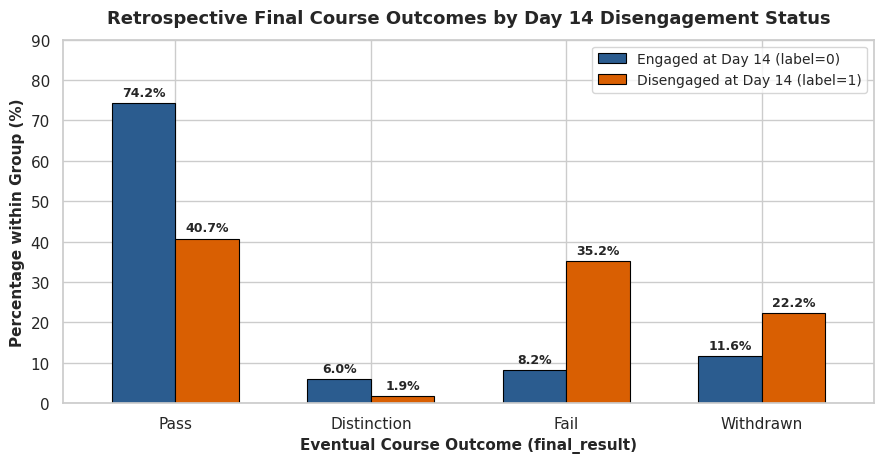

In [8]:
# Cross-tabulate final_result by early disengagement target label
crosstab_counts = pd.crosstab(eda_df["label"], eda_df["final_result"])
crosstab_pct = pd.crosstab(eda_df["label"], eda_df["final_result"], normalize="index") * 100

print("=" * 60)
print("RETROSPECTIVE FINAL OUTCOMES (COUNTS)")
print("=" * 60)
display(crosstab_counts)

print("\n" + "=" * 60)
print("RETROSPECTIVE FINAL OUTCOMES (ROW PERCENTAGES %)")
print("=" * 60)
display(crosstab_pct.round(2))

# Visualization
fig, ax = plt.subplots(figsize=(9, 4.8))
outcomes_order = ["Pass", "Distinction", "Fail", "Withdrawn"]
crosstab_pct_reordered = crosstab_pct[outcomes_order]

crosstab_pct_reordered.T.plot(
    kind="bar",
    ax=ax,
    color=palette,
    edgecolor="black",
    linewidth=0.8,
    width=0.65
)

ax.set_title("Retrospective Final Course Outcomes by Day 14 Disengagement Status", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Eventual Course Outcome (final_result)", fontsize=11, fontweight="bold")
ax.set_ylabel("Percentage within Group (%)", fontsize=11, fontweight="bold")
ax.set_xticklabels(outcomes_order, rotation=0, fontsize=11)
ax.legend(["Engaged at Day 14 (label=0)", "Disengaged at Day 14 (label=1)"], fontsize=10, loc="upper right")
ax.set_ylim(0, 90)

for p in ax.patches:
    h = p.get_height()
    if h > 1.0:
        ax.annotate(f"{h:.1f}%",
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom',
                    xytext=(0, 3), textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


### Interpretation of Analysis 7:
1. **What the plot shows:**
   - **Engaged Cohort at Day 14 ($y=0$):**
     - **80.2% successfully passed** (74.2% Pass, 6.0% Distinction).
     - Only **8.2% Failed** and **11.6% Withdrew** later in the semester.
   - **Disengaged Cohort at Day 14 ($y=1$):**
     - **57.4% ended in adverse outcomes** (35.2% Fail, 22.2% Withdrawn).
     - Only 42.6% scraped a pass, and only 1 student achieved Distinction.
2. **Comparison:**
   - Learners labeled as disengaged at Day 14 are **4.3x more likely to fail** (35.2% vs 8.2%) and **nearly 2x more likely to withdraw** (22.2% vs 11.6%) than engaged learners.
3. **Validation of Target Definition:**
   - This validates that our Day 14 multi-criteria target is capturing **clinically and pedagogically meaningful disengagement** that strongly correlates with end-of-term academic failure.


---
## Final Summary & Key Findings

### 1. Three Most Important Behavioral Findings
1. **Volume Deficit is Immediate and Severe:**  
   Learners who disengage in Days 15–42 click over **4.4x less frequently** (median: 39.5 clicks vs 175.5 clicks) during the first two weeks.
2. **Early Inactivity Gaps Signal Risk:**  
   Disengaged learners experience median inactivity streaks of **7 consecutive days** (half the observation period) vs **3 days** for retained learners.
3. **Consistency Matters More than Spikes:**  
   Retained learners build consistent daily study habits (active on median 8 out of 15 days), whereas disengaged learners average only 3 active days.

---

### 2. Strongest Candidate Signals for Feature Engineering (Days 0–14)
- **Volume Signals:** Total early clicks, log-transformed clicks, clicks per active day.
- **Inactivity Signals:** Longest consecutive zero-click streak, recency (days since last interaction at Day 14).
- **Consistency Signals:** Number of active days, proportion of active days ($rac{	ext{active\_days}}{15}$).
- **Trend Signals:** Weekly click delta $(	ext{Week 2} - 	ext{Week 1})$ and ratio $(rac{	ext{Week 2}}{	ext{Week 1}})$.

---

### 3. Weak or Uninformative Signals
- **Early Assessment Signals:** For `AAA-2013J`, **zero assessments are due in Days 0–14** (TMA 01 is due Day 19). Therefore, early assessment submission features are unavailable for this module and must be omitted.

---

### 4. Data Constraints & Limitations Discovered
- **Class Imbalance:** 14.52% positive rate requires stratified cross-validation and recall/PR-AUC prioritization.
- **Module Specificity:** All findings are derived from `AAA-2013J` (372 eligible students). Generalizing to modules with early Week 1 assessments would require presentation-specific assessment handling.

---
**Phase 3 Complete:** Ready to proceed to **Phase 4: Temporal Feature Engineering**.
